Text(0.5, 1.0, 'Computational cost')

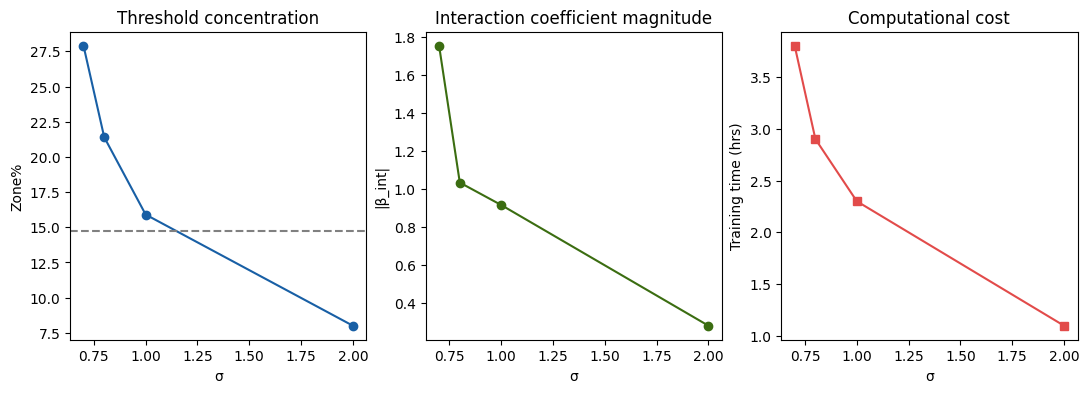

In [3]:
import matplotlib.pyplot as plt
import numpy as np
sigmas = [2.0, 1.0, 0.8, 0.7]
data = {
    'σ':           [2.0,    1.0,    0.8,    0.7],
    'Zone%':       [8.0,    15.9,   21.4,   27.9],
    'β_int':       [-0.282, -0.916, -1.034, -1.753],
    'p_int':       [0.600,  0.114,  0.078,  0.009],
    'Training hr': [1.1,    2.3,    2.9,    3.8]
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(sigmas, data['Zone%'], 'o-', color='#185FA5')
axes[0].axhline(14.7, color='gray', linestyle='--', label='LHS baseline')
axes[0].set_xlabel('σ'); axes[0].set_ylabel('Zone%'); axes[0].set_title('Threshold concentration')

axes[1].plot(sigmas, np.abs(data['β_int']), 'o-', color='#3B6D11')
axes[1].set_xlabel('σ'); axes[1].set_ylabel('|β_int|')
axes[1].set_title('Interaction coefficient magnitude')

axes[2].plot(sigmas, data['Training hr'], 's-', color='#E24B4A')
axes[2].set_xlabel('σ'); axes[2].set_ylabel('Training time (hrs)')
axes[2].set_title('Computational cost')

In [ ]:

#Conformal plot
alphas = np.linspace(0.05, 0.50, 20)
empirical_coverage = []

for alpha in alphas:
    # Compute conformal quantile on calibration set
    q = np.quantile(cal_scores, np.ceil((1-alpha)*(len(cal_scores)+1))/len(cal_scores))
    # Check coverage on test set
    covered = ((true_I_test >= pred_I_test - q) & 
               (true_I_test <= pred_I_test + q)).mean()
    empirical_coverage.append(covered)

plt.figure(figsize=(5, 5))
plt.plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
plt.plot(1-alphas, empirical_coverage, 'o-', color='#185FA5', label='Conformal PI')
plt.xlabel('Nominal coverage (1-α)'); plt.ylabel('Empirical coverage')
plt.title('Conformal prediction calibration')